In [1]:
import pandas as pd

In [2]:
traffic = pd.read_csv("../data/Full_Dataset_Cycling.csv")

### Train a model for one specific location first

In [3]:
traffic["Start_Time"] = pd.to_datetime(traffic["Start_Time"])
traffic["End_Time"] = pd.to_datetime(traffic["End_Time"])

In [26]:
traffic_one_loc = traffic[(traffic["Site_ID"] == "Location_Tag_1")].groupby("End_Time")["Count"].sum().reset_index()

In [27]:
traffic_one_loc.shape

(236932, 2)

In [6]:
traffic_one_loc.head()

,End_Time,Count
0,2019-08-01 00:15:00,1.0
1,2019-08-01 00:30:00,0.0
2,2019-08-01 00:45:00,1.0
3,2019-08-01 01:00:00,0.0
4,2019-08-01 01:15:00,1.0


### Features main ideas

In [38]:
# Let n(t) be the number of bikes counted during the time interval t

# We extract the following past data as features
# - intraday trend: n(t - 1 interval), n(t - 2 interval), n(t - 3 interval), i.e. previous 3 time intervals
# - daily trend: n(t - 1 day), n(t - 2 day), n(t - 3 day), i.e. same time interval for the past 3 days
# - weekly trend: n(t - 1 week), n(t - 2 week), n(t - 3 week), i.e. same time interval for the last 3 weeks
#   (e.g. prev Fri, prev prev Fri, etc.)
# - monthly trend: n(t - 1 month), n(t - 2 month), n(t - 3 month), i.e. same time interval for the last 3 months
#   (e.g. to predict a time interval in May, we use same day same interval in Apr, Mar and Feb)
# - yearly trend: n(t - 1 year), n(t - 2 year), n(t - 3 year), i.e. same time interval for the last 3 years
#   (e.g. to predict a time interval in 2024, we use same day same interval in 2023, 2022 and 2021)

In [28]:
traffic_one_loc["CountIntradayMinus1"] = traffic_one_loc["Count"].shift(1)
traffic_one_loc["CountIntradayMinus2"] = traffic_one_loc["Count"].shift(2)
traffic_one_loc["CountIntradayMinus3"] = traffic_one_loc["Count"].shift(3)

In [29]:
traffic_one_loc_train = traffic_one_loc[traffic_one_loc["End_Time"].dt.year.isin([2020,2021,2022])]
traffic_one_loc_test = traffic_one_loc[traffic_one_loc["End_Time"].dt.year.isin([2023])]

In [30]:
traffic_one_loc_train

,End_Time,Count,CountIntradayMinus1,CountIntradayMinus2,CountIntradayMinus3
14687,2020-01-01 00:00:00,0.0,12.0,1.0,0.0
14688,2020-01-01 00:15:00,3.0,0.0,12.0,1.0
14689,2020-01-01 00:30:00,0.0,3.0,0.0,12.0
14690,2020-01-01 00:45:00,0.0,0.0,3.0,0.0
14691,2020-01-01 01:00:00,0.0,0.0,0.0,3.0
...,...,...,...,...,...
119886,2022-12-31 22:45:00,0.0,0.0,0.0,0.0
119887,2022-12-31 23:00:00,2.0,0.0,0.0,0.0
119888,2022-12-31 23:15:00,2.0,2.0,0.0,0.0
119889,2022-12-31 23:30:00,0.0,2.0,2.0,0.0


In [31]:
from xgboost import XGBRegressor
from sklearn.metrics import root_mean_squared_error

In [32]:
# set X and y
X = traffic_one_loc_train[["CountIntradayMinus1", "CountIntradayMinus2", "CountIntradayMinus3"]]
y = traffic_one_loc_train["Count"]

# train the model
xgbr = XGBRegressor(n_estimators=100, random_state=42)
xgbr.fit(X, y)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [35]:
test_X = traffic_one_loc_test[["CountIntradayMinus1", "CountIntradayMinus2", "CountIntradayMinus3"]]
test_y = traffic_one_loc_test["Count"]
test_y_pred = xgbr.predict(test_X)

In [37]:
rmse = root_mean_squared_error(test_y, test_y_pred)
print(f"performance: model=XGBRegressor, rmse={rmse:.4f}")

performance: model=XGBRegressor, rmse=3.4174


### Plot actual vs prediction(made at t - 1 time interval)

In [49]:
traffic_one_loc_test["CountPredAtIntradayMinus1"] = test_y_pred

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="darkgrid")

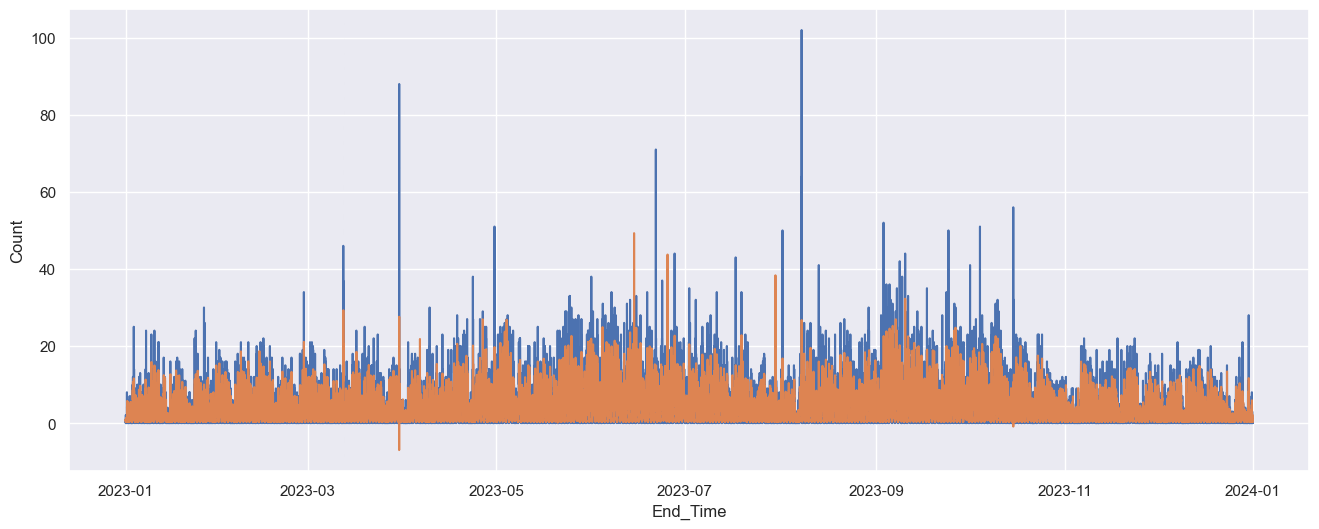

In [52]:
plt.figure(figsize=(16,6))
sns.lineplot(data=traffic_one_loc_test, x="End_Time", y="Count")
sns.lineplot(data=traffic_one_loc_test, x="End_Time", y="CountPredAtIntradayMinus1");